In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import DataLoader, Dataset, random_split,Subset
from torchvision.datasets import ImageFolder
from sklearn.metrics import  confusion_matrix
from torch.utils.data.sampler import WeightedRandomSampler
from torchsummary import summary
import torchvision.transforms as transforms
from torchvision.datasets import CIFAR10


In [2]:
transform=transforms.Compose([
    transforms.Resize((224,224)),    
    transforms.ToTensor() 
])

In [3]:
cifar10_train = CIFAR10(root='./data', train=True, download=True, transform=transform)
cifar10_test = CIFAR10(root='./data', train=False, download=True, transform=transform)

Files already downloaded and verified
Files already downloaded and verified


In [4]:
model_algo="alexnet"

In [5]:
import sys

# 添加自定义模块的目录到模块搜索路径
sys.path.append('/home/pcdm/Desktop')

# 现在可以导入你的自定义模块
from MJPytorch import *

In [6]:
images=CifarDataset(cifar10_train,decision_mode=False)
generator = torch.Generator()
generator.manual_seed(125)

size = len(images)
valid_size = int(0.2 * size)
test_size=int(0.5*size)
train_size = int(size - test_size-valid_size)

trainset, validset,test_set = random_split(images, (train_size, valid_size,test_size), generator=generator)

In [7]:
# create data loaders
batch_size =32 # larger numbers lead to CUDA running out of memory
train_dl = DataLoader(trainset,shuffle=True, batch_size=batch_size)
valid_dl = DataLoader(validset,shuffle=True, batch_size=batch_size)
criterion = nn.CrossEntropyLoss()

In [8]:
# model_0=model_train(model_algo,train_dl,valid_dl,"0",70)
model_0 = torch.load(f'model_{model_algo}_0_14.pth')

In [9]:
summary(model_0,(3,299,299))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 74, 74]          23,296
              ReLU-2           [-1, 64, 74, 74]               0
         MaxPool2d-3           [-1, 64, 36, 36]               0
            Conv2d-4          [-1, 192, 36, 36]         307,392
              ReLU-5          [-1, 192, 36, 36]               0
         MaxPool2d-6          [-1, 192, 17, 17]               0
            Conv2d-7          [-1, 384, 17, 17]         663,936
              ReLU-8          [-1, 384, 17, 17]               0
            Conv2d-9          [-1, 256, 17, 17]         884,992
             ReLU-10          [-1, 256, 17, 17]               0
           Conv2d-11          [-1, 256, 17, 17]         590,080
             ReLU-12          [-1, 256, 17, 17]               0
        MaxPool2d-13            [-1, 256, 8, 8]               0
AdaptiveAvgPool2d-14            [-1, 25

In [10]:
train_loss,train_accu,confusion_matrix_train=evaluate_model(model_0,train_dl,train_size,'0',mode='eval')
train_loss,train_accu

(0.8811770243644714, 0.7038666666666666)

In [11]:
valid_loss,valid_accu,confusion_matrix_valid=evaluate_model(model_0,valid_dl,valid_size,'0',mode='eval')
valid_loss,valid_accu

(0.9464354838371277, 0.6777)

In [12]:
each_accu=np.diag(confusion_matrix_train)/confusion_matrix_train.sum(1)
each_accu

airplane      0.676892
automobile    0.772851
bird          0.536975
cat           0.496911
deer          0.738665
dog           0.606242
frog          0.817385
horse         0.713701
ship          0.837148
truck         0.831270
dtype: float64

In [13]:
targetF=[x  for x in each_accu.nsmallest(3).index.map(trainset.dataset.classess)]
targetF

[3, 2, 5]

In [14]:
# 將資料切分成true and false
def split_data(model_0,data_dl,split_mode,targetF):
    model_0.eval()

    flat_data=[]
    flat_true=[]
    with torch.no_grad():

        for (data,target,idx) in data_dl:
            data,target=data.cuda(),target.cuda()
            out = model_0(data)
            _, y_pred_tag = torch.max(out, dim = 1) 
         

            # print(loss)
            for idx,t,pred in zip(idx,target,y_pred_tag):
                
                if(split_mode=='T'):
                    if t in targetF:
                        flat_true.append(len(data_dl.dataset.dataset.classes))
                    else:
                        flat_true.append(t.cpu().item())  
                else:
                    if t in targetF:
                        flat_true.append(t.cpu().item())
                    else:
                        flat_true.append(len(data_dl.dataset.dataset.classes)) 
                
                            
            flat_data.extend(data.cpu().numpy()) 

    return flat_data,flat_true

In [15]:
#建立dataset class
class TandFDataset(Dataset):
    def __init__(self, x,y):
        super().__init__()
        self.x = x        
        self.y = y
        self.classes={label: i for i, label in enumerate (sorted(list(set(self.y))))}
    
    def __len__(self):
        return len(self.y)
   
    def __getitem__(self,idx):

        image=self.x[idx]
        # label=torch.tensor(self.y[idx])

        label=torch.tensor(self.classes[self.y[idx]])

        return image,label,idx
    def get_labels(self):
        return [self.classes[label] for label in self.y]
    

In [16]:
#將資料切分後建立dataset與dataloader
from torchsampler import ImbalancedDatasetSampler
data_T,label_T=split_data(model_0,train_dl,split_mode="T",targetF=targetF)
data_F,label_F=split_data(model_0,train_dl,split_mode="F",targetF=targetF)

Tdataset=TandFDataset(data_T,label_T)
Fdataset=TandFDataset(data_F,label_F)
Fdl=DataLoader(Fdataset, batch_size=batch_size)
Tdl=DataLoader(Tdataset, batch_size=batch_size)
print(set(label_T))
print(set(label_F))

{0, 1, 4, 6, 7, 8, 9, 10}
{3, 10, 2, 5}


In [17]:
Fdataset.classes

{2: 0, 3: 1, 5: 2, 10: 3}

In [18]:
#將資料切分後建立dataset與dataloader

data_T_v,label_T_v=split_data(model_0,valid_dl,split_mode="T",targetF=targetF)
data_F_v,label_F_v=split_data(model_0,valid_dl,split_mode="F",targetF=targetF)

Tdataset_v=TandFDataset(data_T_v,label_T_v)
Fdataset_v=TandFDataset(data_F_v,label_F_v)
Fdl_v=DataLoader(Fdataset_v, shuffle=True, batch_size=batch_size)
Tdl_v=DataLoader(Tdataset_v, shuffle=True, batch_size=batch_size)

In [19]:
sum=[0]*11
for d,t,_ in Tdataset:
    for i in range(11):
        if(t==i):
            sum[i]+=1
sum

[1467, 1466, 1588, 1484, 1467, 1529, 1535, 4464, 0, 0, 0]

/home/pcdm/anaconda3/envs/ming/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch=0,train_loss=1.0890403183619182,train_accu=0.6332
Epoch=0,valid_loss=1.2192003379821776,valid_accu=0.5664
0
Epoch=1,train_loss=0.960626131884257,train_accu=0.6757333333333333
Epoch=1,valid_loss=1.046980502510071,valid_accu=0.629
0
Epoch=2,train_loss=0.90897648935318,train_accu=0.6842666666666667
Epoch=2,valid_loss=1.0007529984474182,valid_accu=0.6392
0
Epoch=3,train_loss=0.8557009067853292,train_accu=0.7069333333333333
Epoch=3,valid_loss=0.9614263771057129,valid_accu=0.6548
0
Epoch=4,train_loss=0.8226449544270833,train_accu=0.7135333333333334
Epoch=4,valid_loss=0.9883686174392701,valid_accu=0.6414
Epoch=5,train_loss=0.8172738896369934,train_accu=0.7182
Epoch=5,valid_loss=0.9492644773483276,valid_accu=0.6548
Epoch=6,train_loss=0.773655593585968,train_accu=0.7350666666666666
Epoch=6,valid_loss=0.9178720779418945,valid_accu=0.6669
0
Epoch=7,train_loss=0.7753430296262105,train_accu=0.7371333333333333
Epoch=7,valid_loss=0.9115088249206543,valid_accu=0.6708
0
Epoch=8,train_loss=0.76173

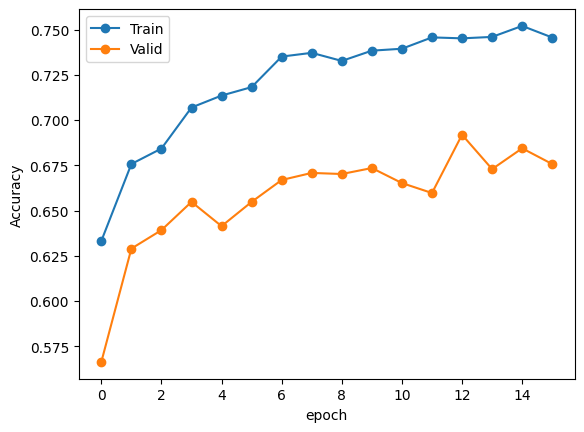

In [20]:
#訓練模型T、F、decision
model_T=model_train(model_algo,Tdl,Tdl_v,"T",70)
# model_T=torch.load(f'model_{model_algo}_T_1.pth')

In [21]:
set(Tdataset.y)

{0, 1, 4, 6, 7, 8, 9, 10}

In [22]:
summary(model_T,(3,299,299))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 74, 74]          23,296
              ReLU-2           [-1, 64, 74, 74]               0
         MaxPool2d-3           [-1, 64, 36, 36]               0
            Conv2d-4          [-1, 192, 36, 36]         307,392
              ReLU-5          [-1, 192, 36, 36]               0
         MaxPool2d-6          [-1, 192, 17, 17]               0
            Conv2d-7          [-1, 384, 17, 17]         663,936
              ReLU-8          [-1, 384, 17, 17]               0
            Conv2d-9          [-1, 256, 17, 17]         884,992
             ReLU-10          [-1, 256, 17, 17]               0
           Conv2d-11          [-1, 256, 17, 17]         590,080
             ReLU-12          [-1, 256, 17, 17]               0
        MaxPool2d-13            [-1, 256, 8, 8]               0
AdaptiveAvgPool2d-14            [-1, 25

Epoch=0,train_loss=0.9417476064046224,train_accu=0.6212666666666666
Epoch=0,valid_loss=0.9300803721427917,valid_accu=0.622
0
Epoch=1,train_loss=0.8700056213696797,train_accu=0.6579333333333334
Epoch=1,valid_loss=0.8702758289337158,valid_accu=0.6525
0
Epoch=2,train_loss=0.8341777939796448,train_accu=0.6702
Epoch=2,valid_loss=0.8600994529724121,valid_accu=0.6535
0
Epoch=3,train_loss=0.823602507909139,train_accu=0.6817333333333333
Epoch=3,valid_loss=0.8513283445358276,valid_accu=0.6609
0
Epoch=4,train_loss=0.8024575380643209,train_accu=0.684
Epoch=4,valid_loss=0.829303792667389,valid_accu=0.6631
0
Epoch=5,train_loss=0.7739696804364522,train_accu=0.7007333333333333
Epoch=5,valid_loss=0.8447375210762024,valid_accu=0.6616
Epoch=6,train_loss=0.7681005593935648,train_accu=0.7098
Epoch=6,valid_loss=0.7816539070129395,valid_accu=0.6962
0
Epoch=7,train_loss=0.765348101011912,train_accu=0.7043333333333334
Epoch=7,valid_loss=0.8014568755149841,valid_accu=0.6753
Epoch=8,train_loss=0.7626282934506734

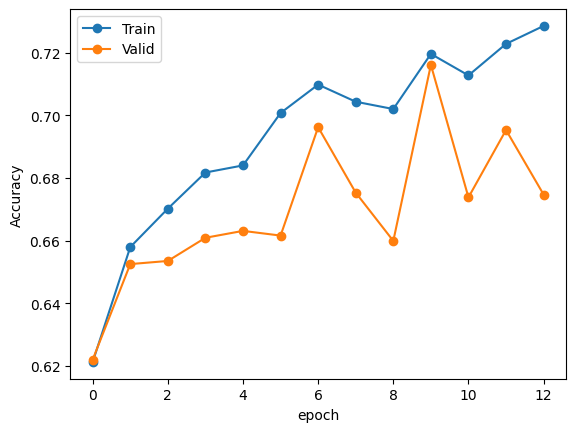

In [23]:
model_F=model_train(model_algo,Fdl,Fdl_v,"F",70)
#model_F=torch.load(f'model_{model_algo}_F_0.pth')

In [24]:
#模型表現
def evaluate_model(model,data_dl,size,data_name,mode=None):
        model.to(device)
        ######################    
        # validate the model #
        ######################
        torch.cuda.empty_cache()
        total_loss = 0
        accu = 0
        flat_true=[]
        flat_pred=[]
        with torch.no_grad():
            model.eval()   

            for data, target,idx in data_dl:

                    data,target=data.to(device),target.to(device)
                    out= model(data)
                    _, y_pred_tag = torch.max(out, dim = 1)
                    
                    loss = criterion(out, target)
                    # print(target)
                    flat_true.extend(target.cpu().numpy())
                    flat_pred.extend(y_pred_tag.cpu().numpy())

                    total_loss+= loss.item()*data.size(0)
                    correct=torch.sum(y_pred_tag == target).item()
                    accu += correct      

            total_loss=total_loss/size
            accu=accu/size

        a=sorted(set(flat_true))

        
   
        if(mode=='eval'):
            if(data_name=='decision'):
                confusion_matrix_valid=pd.DataFrame(confusion_matrix(flat_true, flat_pred),columns=list(a),index=list(a))
            elif(data_name=='T' or data_name=='F'):
                confusion_matrix_valid=pd.DataFrame(confusion_matrix(flat_true, flat_pred))
            else:
                idxtoclass={v:k for k,v in data_dl.dataset.dataset.classes}
                confusion_matrix_valid= pd.DataFrame(confusion_matrix(flat_true, flat_pred),columns=list(a),index=list(a)).rename(columns=idxtoclass,index=idxtoclass)
            return total_loss,accu,confusion_matrix_valid
        else:
            return total_loss,accu


In [25]:
T_loss,T_accu,confusion_matrix_T_train=evaluate_model(model_T,Tdl,len(Tdataset),'T',mode='eval')
T_loss,T_accu

(0.7194829007784526, 0.7540666666666667)

In [26]:
F_loss,F_accu,confusion_matrix_F_train=evaluate_model(model_F,Fdl,len(Fdataset),'F',mode='eval')
F_loss,F_accu

(0.7400938275973002, 0.7219333333333333)

In [27]:
T_valid_loss,T_valid_accu,confusion_matrix_T_valid=evaluate_model(model_T,Tdl_v,len(Tdataset_v),'T',mode='eval')
T_valid_loss,T_valid_accu

(0.853917273426056, 0.6919)

In [28]:
F_valid_loss,F_valid_accu,confusion_matrix_F_valid=evaluate_model(model_F,Fdl_v,len(Fdataset_v),'F',mode='eval')
F_valid_loss,F_valid_accu

(0.7292342448234558, 0.7161)

In [29]:
#全部模型裝在一起的表現
def total_model_evaluate(data_dl,size,model_0,model_T,model_F):
    total_loss = 0
    accu = 0
    flat_true=[]
    flat_pred=[]
    results = []
    inverse_Tdataset_classes = {v: k for k, v in Tdataset.classes.items()}
    inverse_Fdataset_classes = {v: k for k, v in Fdataset.classes.items()}
    with torch.no_grad():
        for data,target,idx in data_dl:
   
            data,target=data.to(device),target.to(device) 
            
            for d,t,idx in zip(data,target,idx):
                
                pred_F=inverse_Fdataset_classes[torch.max(model_F(d.unsqueeze(0)), dim = 1).indices.item()]
                pred_T=inverse_Tdataset_classes[torch.max(model_T(d.unsqueeze(0)), dim = 1).indices.item()]
                pred_0=torch.max(model_0(d.unsqueeze(0)), dim = 1).indices.item()
                
                    # Record results in a dictionary
                result_dict = {
                    'Index': idx.item(),
                    'Target': t.item(),
                    'Pred_F': pred_F,
                    'Pred_T': pred_T,
                    'Pred_0': pred_0,
                    'Match_F': pred_F == t.item(),
                    'Match_T': pred_T == t.item(),
                    'Match_0': pred_0 == t.item()
                }

                # Append result dictionary to the results list
                results.append(result_dict)

    # Create a DataFrame from the results list
    df_results = pd.DataFrame(results)
    return  df_results

In [30]:
df_results=total_model_evaluate(train_dl,train_size,model_0,model_T,model_F)
df_results

,Index,Target,Pred_F,Pred_T,Pred_0,Match_F,Match_T,Match_0
0,37264,1,10,9,9,False,False,False
1,42274,5,5,10,5,True,False,True
2,22197,9,10,9,9,False,True,True
3,12314,9,10,9,9,False,True,True
4,29939,4,2,4,4,False,True,True
...,...,...,...,...,...,...,...,...
14995,3871,1,10,1,1,False,True,True
14996,20771,6,10,6,6,False,True,True
14997,47317,0,10,0,0,False,True,True
14998,9298,3,5,10,3,False,False,True


In [31]:
sum=0
for i in range(len(df_results['Match_F'])):
   if df_results['Match_0'][i]==True and df_results['Match_F'][i]==df_results['Match_T'][i]==False :
      sum+=1
sum

292

In [32]:
sum=0
for i in range(len(df_results['Match_F'])):
   if df_results['Match_T'][i]==True and df_results['Match_F'][i]==df_results['Match_0'][i]==False :
      sum+=1
sum

331

In [33]:
sum=0
for i in range(len(df_results['Match_F'])):
   if df_results['Match_F'][i]==True and df_results['Match_T'][i]==df_results['Match_0'][i]==False :
      sum+=1
sum

822

In [43]:
sum=0
for i in range(len(df_results['Match_F'])):
   if df_results['Match_F'][i]==df_results['Match_T'][i]==df_results['Match_0'][i]==False :
      sum+=1
sum

3289

In [34]:
#全部模型裝在一起的表現
def total_model_evaluate(data_dl,size,model_0,model_T,model_F):
    total_loss = 0
    accu = 0
    flat_true=[]
    flat_pred=[]
    num_0=0
    num_T=0
    num_F=0
    inverse_Tdataset_classes = {v: k for k, v in Tdataset.classes.items()}
    inverse_Fdataset_classes = {v: k for k, v in Fdataset.classes.items()}
    with torch.no_grad():
        for data,target,idx in data_dl:
            outputs=[]
            data,target=data.to(device),target.to(device)
            y_pred_tag=[]
            
            out_0 = model_0(data)
            _, y_pred_0 = torch.max(out_0, dim = 1) 

            out_T = model_T(data)
            _, y_pred_T = torch.max(out_T, dim = 1)

            out_F = model_F(data)
            _, y_pred_F = torch.max(out_F, dim = 1)

            # num_classes = len(data_dl.dataset.dataset.classes)
            # special_class = num_classes 
            
            for pred_0,pred_T,pred_F,d,t in zip(y_pred_0,y_pred_T,y_pred_F,data,target):
                sum_T=0
                sum_F=0
                

                sum_T = 1 if pred_T == 7 else 0
                sum_F = 1 if pred_F == 3 else 0
                    
              
                if sum_T + sum_F != 1:
                    y_pred_tag.append(pred_0.cpu().numpy().item())
                    num_0+=1
                else:
                    if(sum_T ==1):
                        y_pred_tag.append(inverse_Fdataset_classes[pred_F.cpu().numpy().item()])
                        num_F+=1
                    else:
                        y_pred_tag.append(inverse_Tdataset_classes[pred_T.cpu().numpy().item()])
                        num_T+=1
                    # print(sum_T,sum_F)    
            # print(len(outputs))
            # outputs = torch.cat(outputs, dim=0)
            # _, y_pred_tag = torch.max(outputs, dim = 1)
            # loss = criterion(outputs, target)
        
            y_pred_tag=torch.tensor(y_pred_tag).cuda()
            flat_true.extend(target.cpu().numpy())
            flat_pred.extend(y_pred_tag.cpu().numpy())
            # print(y_pred_tag,"--")
            # total_loss+= loss.item()*data.size(0)
           
            correct=torch.sum(y_pred_tag == target).item()
            accu += correct      
    # print(num)
    total_loss=total_loss/size
    accu=accu/size
    idx2class = {v: k for k, v in data_dl.dataset.dataset.classes}
    confusion_matrix_total = pd.DataFrame(confusion_matrix(flat_true, flat_pred)).rename(columns=idx2class, index=idx2class)
    print(num_0,num_T,num_F)
    return total_loss,accu,confusion_matrix_total,sum_F

In [35]:
total_train_loss,total_train_accu,confusion_matrix_total_train,sum=total_model_evaluate(train_dl,train_size,model_0,model_T,model_F)
total_train_loss,total_train_accu,sum

4144 8054 2802


(0.0, 0.7044, 0)

In [36]:
total_valid_loss,total_valid_accu,confusion_matrix_total_valid,sum=total_model_evaluate(valid_dl,valid_size,model_0,model_T,model_F)
total_valid_loss,total_valid_accu,sum

2795 5325 1880


(0.0, 0.6786, 0)

In [44]:
train_losses=[train_loss,T_loss,F_loss,total_train_loss]
train_accuracies=[train_accu,T_accu,F_accu,total_train_accu]
valid_losses=[valid_loss,T_valid_loss,F_valid_loss,total_valid_loss]
valid_accuracies=[valid_accu,T_valid_accu,F_valid_accu,total_valid_accu]

In [45]:
model_algos=['Model_0',"Model_T","Model_F","Total_Model"]
data = {
    'Model': model_algos,
    'Train Loss': train_losses,
    'Train Accuracy': train_accuracies,
    'Valid Loss': valid_losses,
    'Valid Accuracy': valid_accuracies
}
df = pd.DataFrame(data)
df

,Model,Train Loss,Train Accuracy,Valid Loss,Valid Accuracy
0,Model_0,0.881177,0.703867,0.946435,0.6777
1,Model_T,0.719483,0.754067,0.853917,0.6919
2,Model_F,0.740094,0.721933,0.729234,0.7161
3,Total_Model,0.000000,0.704400,0.000000,0.6786


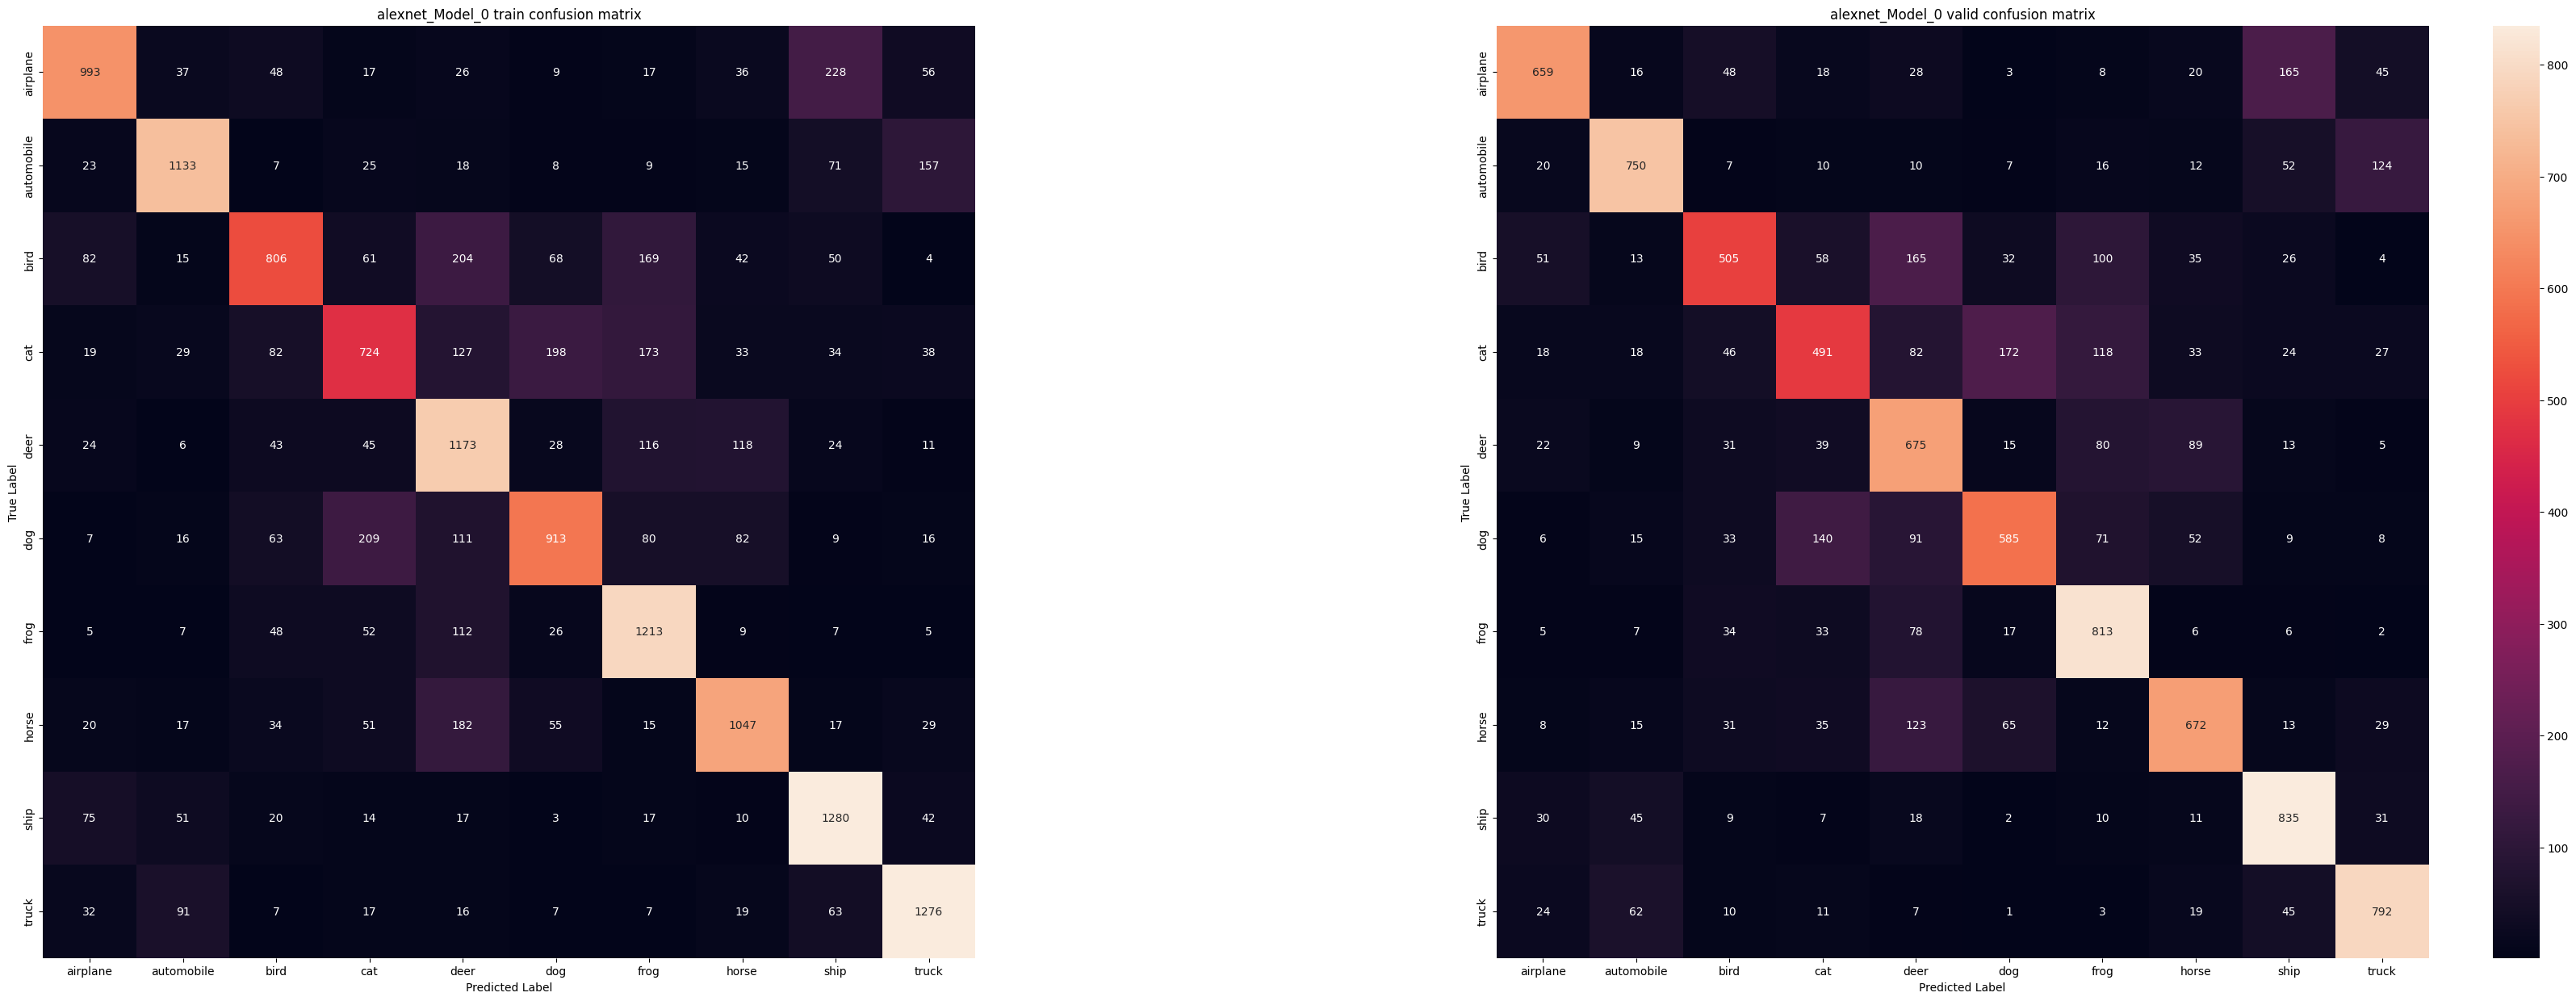

In [46]:
plot_confusion_matrix(confusion_matrix_train,confusion_matrix_valid,"Model_0",model_algo)

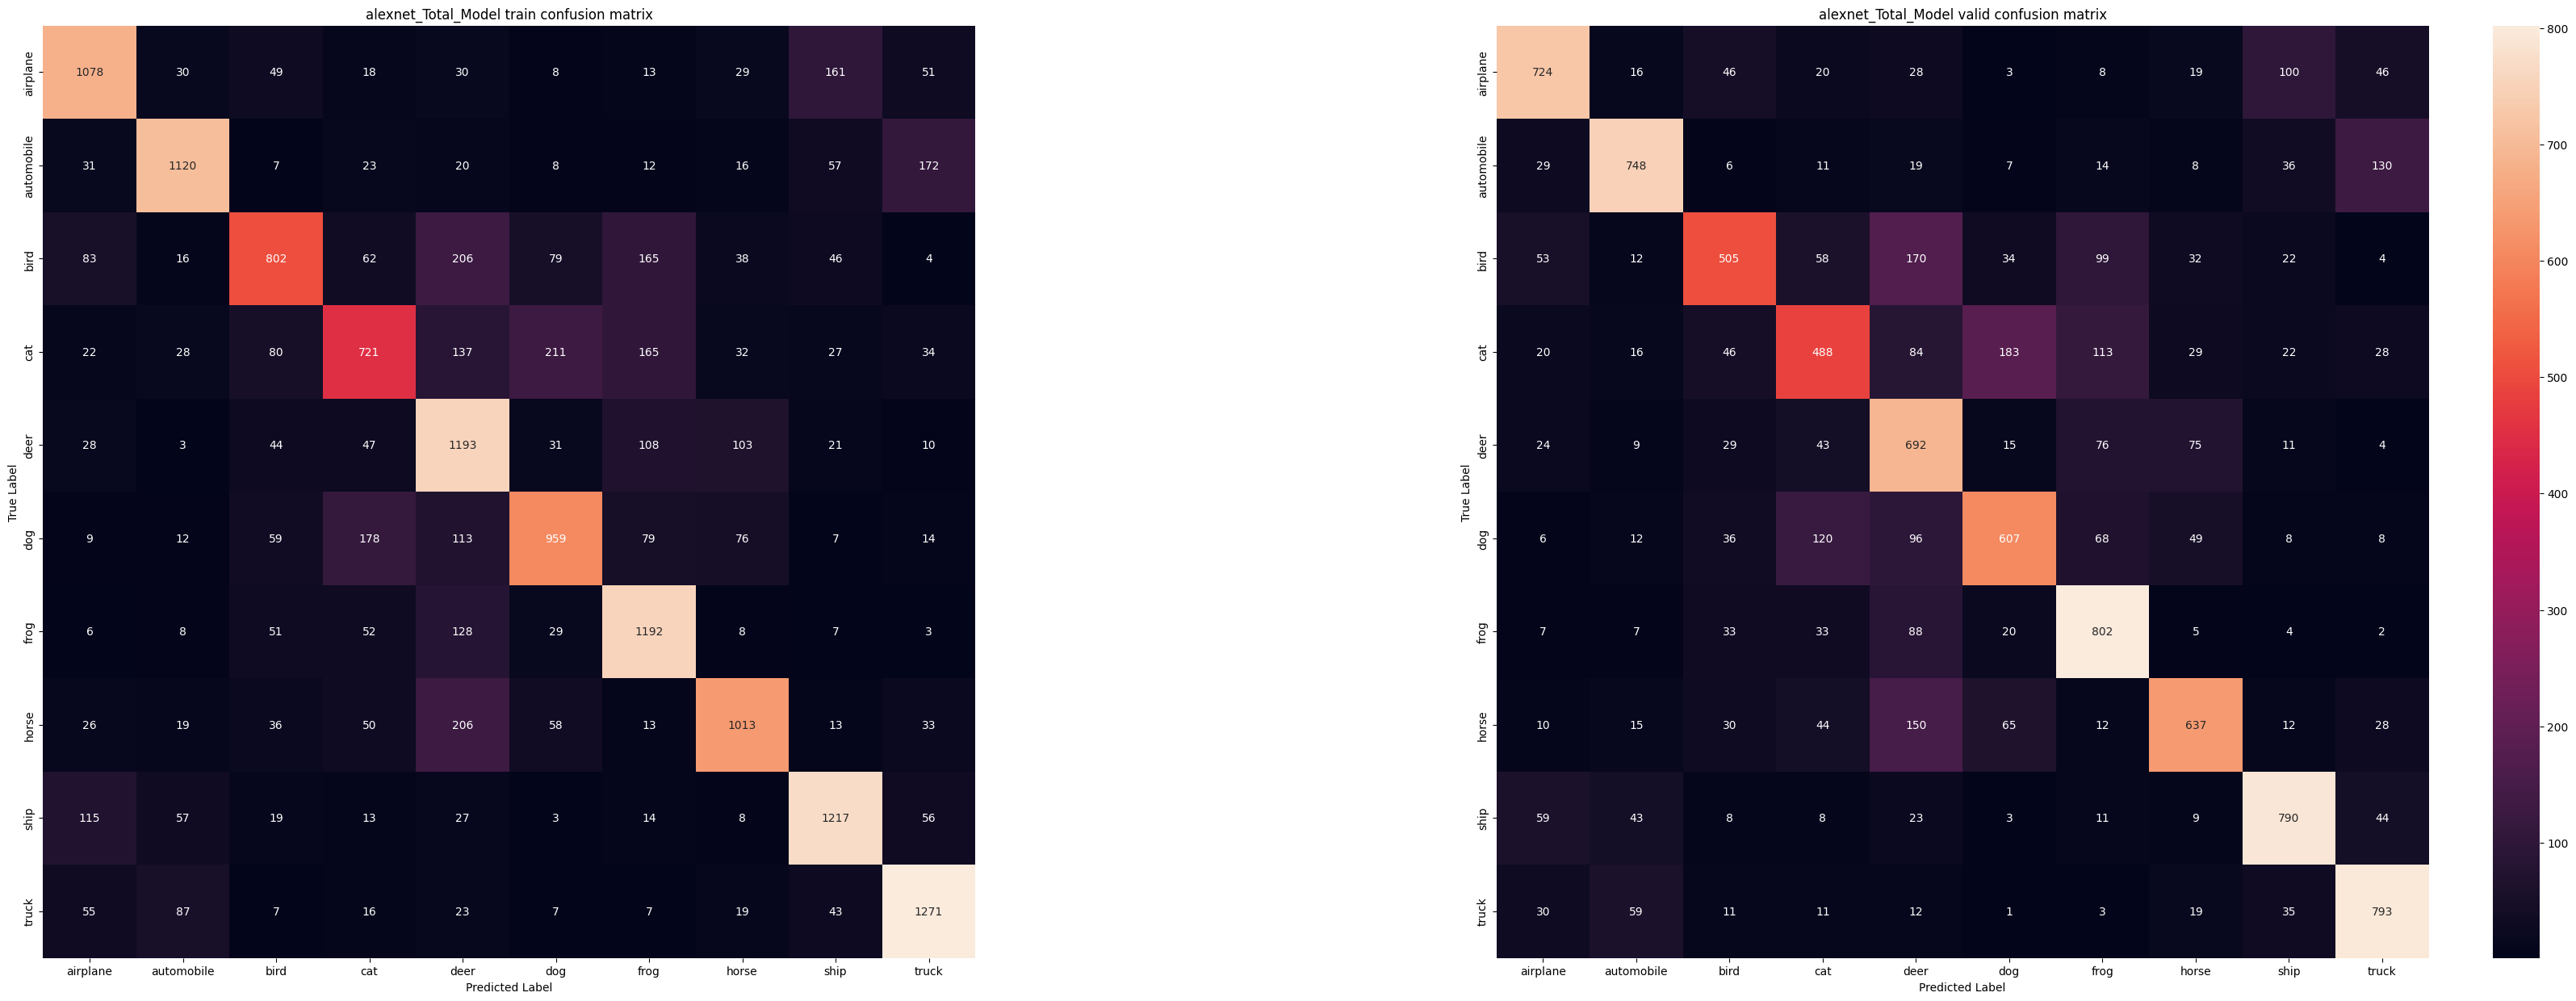

In [40]:
plot_confusion_matrix(confusion_matrix_total_train,confusion_matrix_total_valid,"Total_Model",model_algo)

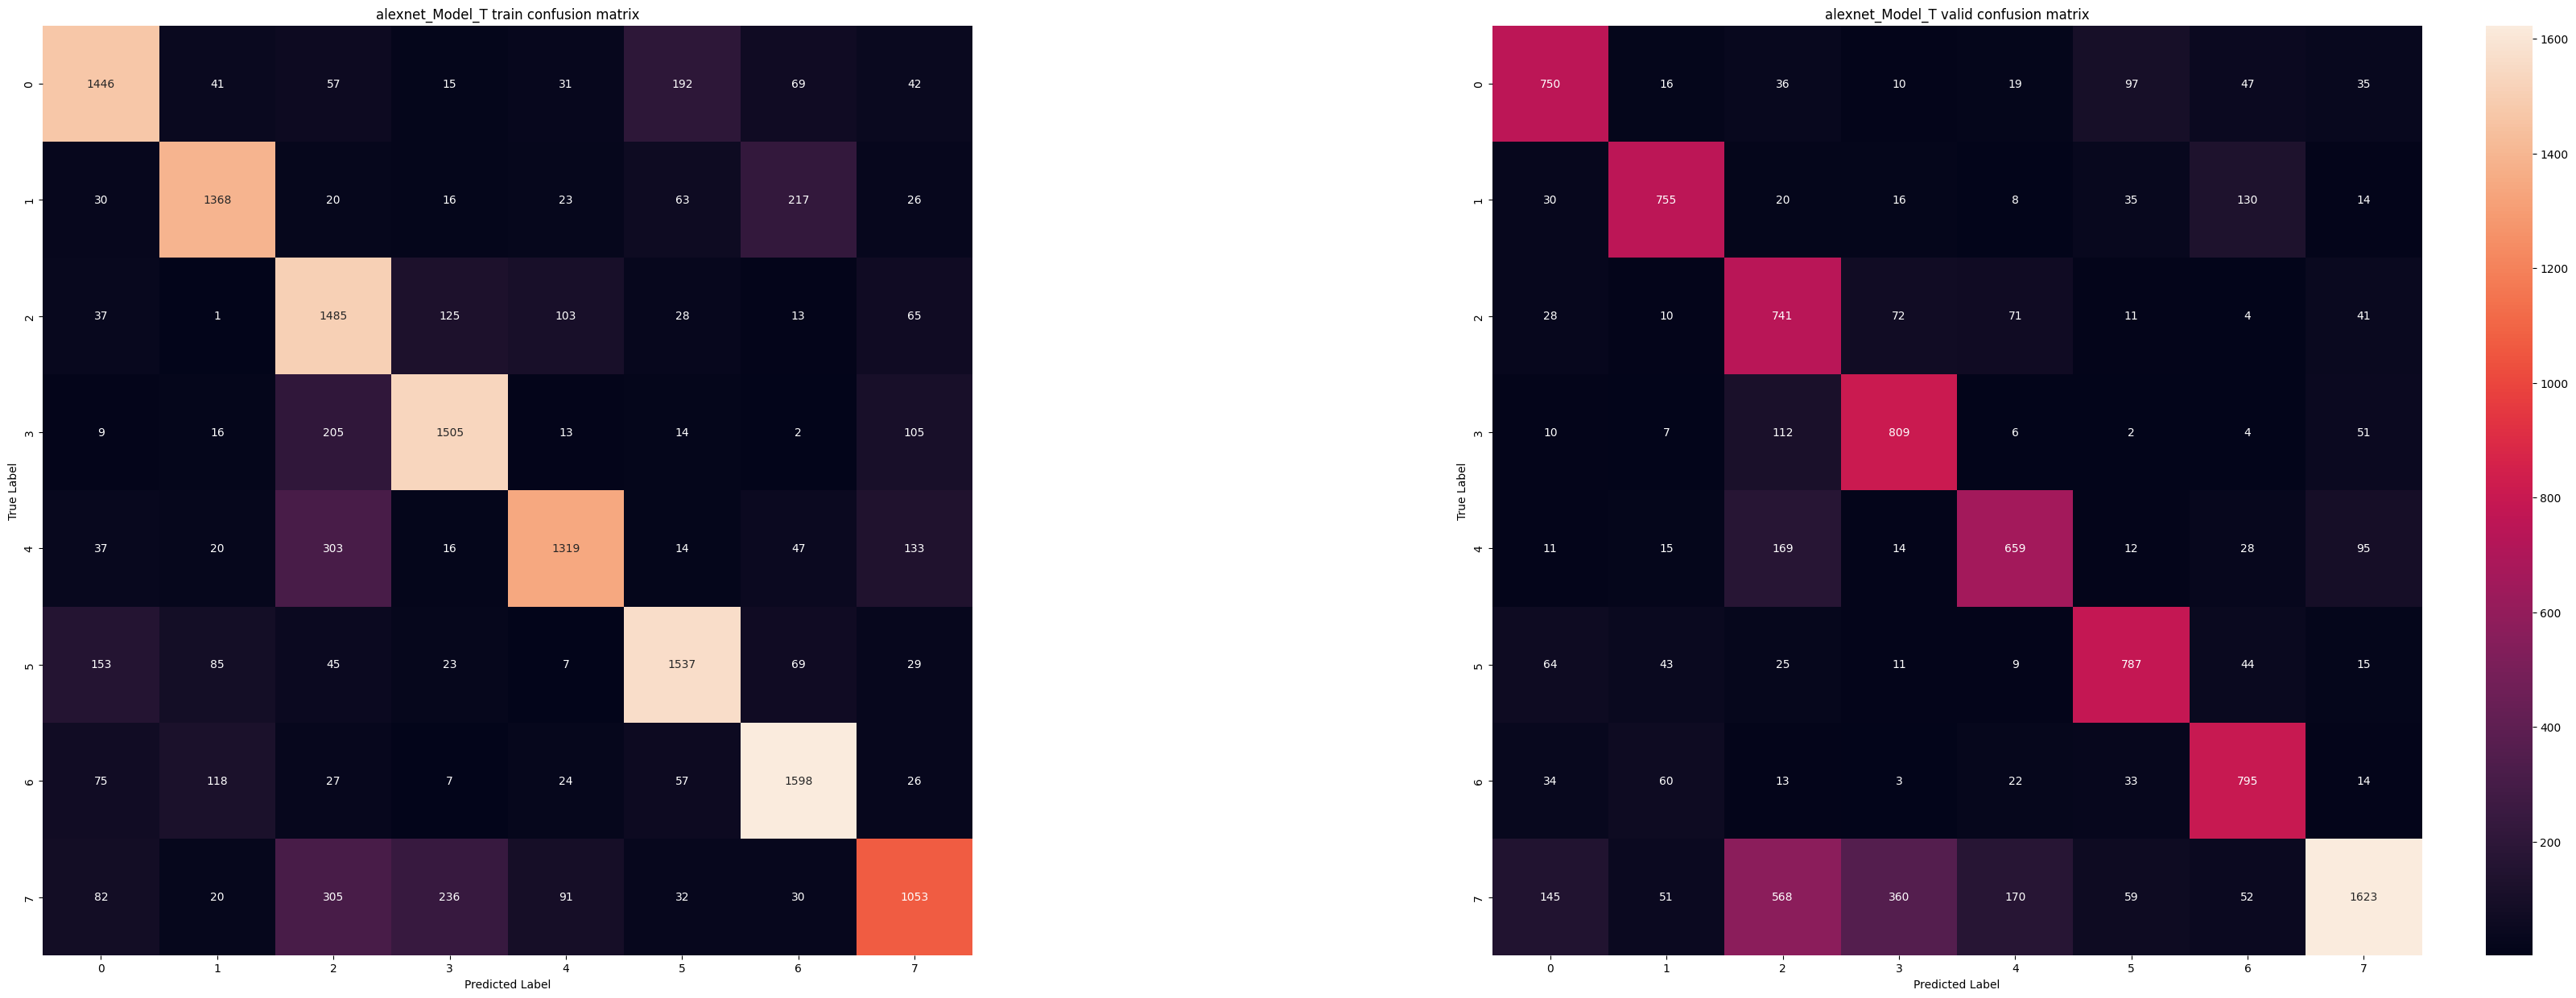

In [41]:
plot_confusion_matrix(confusion_matrix_T_train,confusion_matrix_T_valid,"Model_T",model_algo)

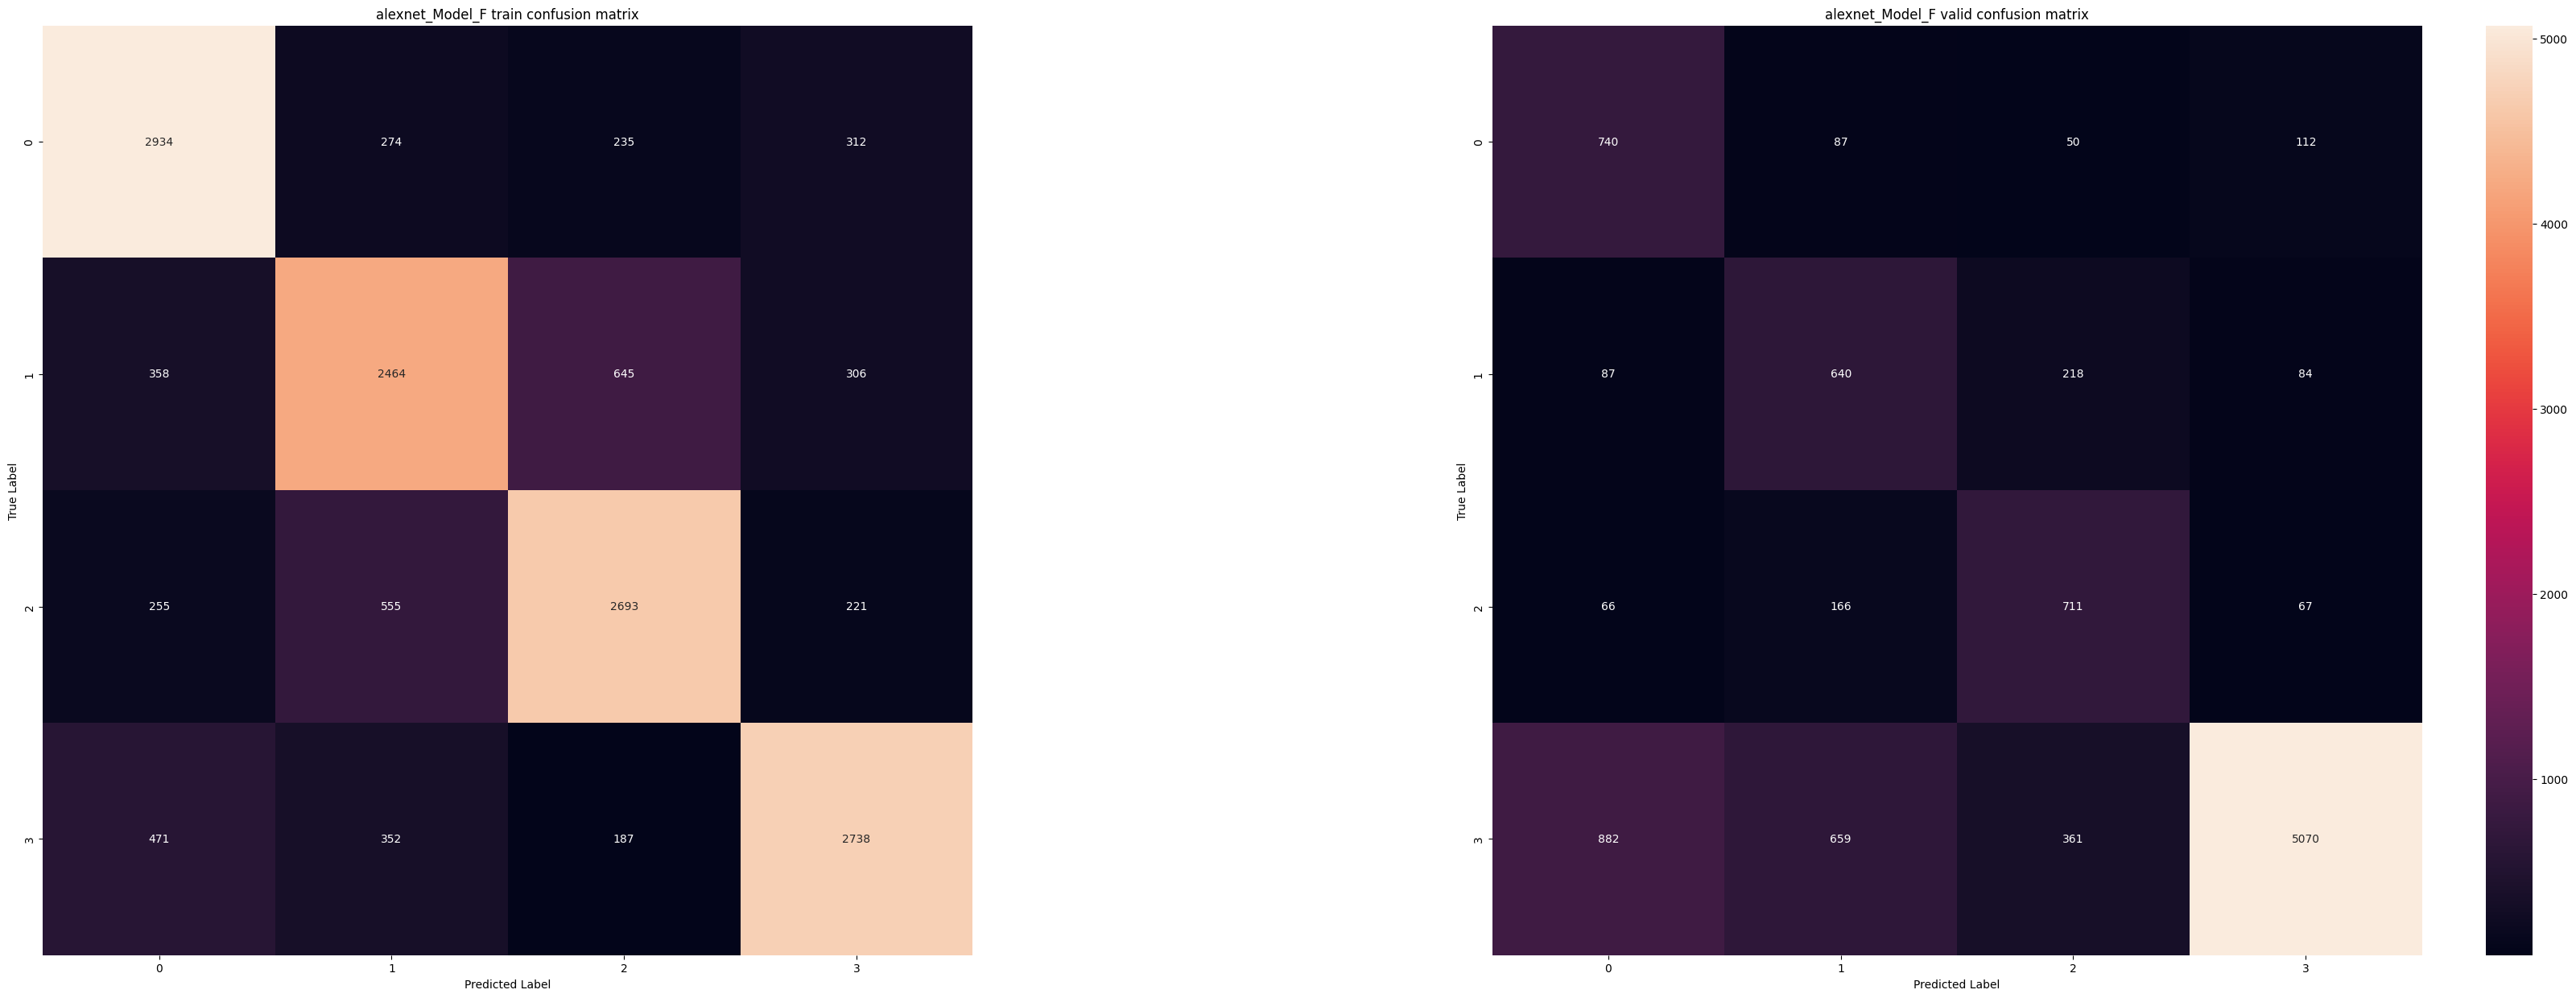

In [42]:
plot_confusion_matrix(confusion_matrix_F_train,confusion_matrix_F_valid,"Model_F",model_algo)